# Reinforcement Learning – Imitation Learning – Assignment 1

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q "stable-baselines3>=2.0" "gymnasium[box2d]" swig

# Part A — Training an Expert RL Agent

### Library: Stable-Baselines3

[Stable-Baselines3](https://stable-baselines3.readthedocs.io/) (SB3) is a set of reliable implementations of reinforcement learning algorithms in PyTorch. We use **PPO (Proximal Policy Optimization)**, a popular on-policy algorithm that works well on continuous-control and discrete-action environments alike. PPO strikes a good balance between sample efficiency and stability, making it a natural first choice for LunarLander-v3.

### Environment

**LunarLander-v3** (discrete actions, 8-dimensional state space, 4 actions):

- State: position (x, y), velocity (vx, vy), angle, angular velocity, two leg contact booleans (r, l).

- Actions: 0 = do nothing, 1 = fire left engine, 2 = fire main engine, 3 = fire right engine.

- Reward: shaped reward for landing between flags, penalises crashing and fuel usage. Solved when the mean reward over 100 episodes exceeds 200.

### Performance Criterion

We consider the agent to be a good expert when it achieves a mean episodic reward >= 200 over 100 evaluation episodes (the standard Gymnasium benchmark for this environment).

In [ ]:
import base64
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from IPython.display import Video, display

SEED = 42
np.random.seed(SEED)

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("logs/videos", exist_ok=True)
os.makedirs("data", exist_ok=True)


# Embed both videos via base64 HTML
def _b64_video(folder, prefix):
    path = sorted(glob.glob(f"{folder}/{prefix}*.mp4"))[-1]
    return base64.b64encode(open(path, "rb").read()).decode()


# Smoke-test the environment
env = gym.make("LunarLander-v3")
obs, _ = env.reset(seed=SEED)
# print("Observation space:", env.observation_space)
# print("Action space:", env.action_space)
# print("Sample observation:", obs)
env.close()

## Training the PPO Agent

We train PPO with:

- 4 parallel environments to collect diverse rollouts.

- 5m total timesteps – sufficient for convergence on LunarLander-v3.

- Default SB3 PPO hyperparameters (learning rate 3e-4, clip range 0.2, GAE $\lambda=0.95$, $\gamma=0.99$), which are well-tuned for this task.

An `EvalCallback` runs the current policy in a separate environment every 10k steps and records the mean reward, letting us plot the learning curve.

In [ ]:
N_ENVS = 4
TOTAL_TIMESTEPS = 5_000_000
EVAL_FREQ = 10_000
N_EVAL_EPISODES = 20

In [ ]:
def train_ppo(timesteps=TOTAL_TIMESTEPS, tag=None):
    train_env = make_vec_env('LunarLander-v3', n_envs=N_ENVS, seed=SEED)
    eval_env = Monitor(gym.make('LunarLander-v3'))

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f'models/{tag}',
        log_path=f'logs/{tag}',
        eval_freq=max(EVAL_FREQ // N_ENVS, 1),
        n_eval_episodes=N_EVAL_EPISODES,
        deterministic=True,
        render=False,
        verbose=0,
    )

    model = PPO(
        policy='MlpPolicy',
        env=train_env,
        verbose=0,
        seed=SEED,
    )

    model.learn(total_timesteps=timesteps, callback=eval_callback, progress_bar=True)

    train_env.close()
    eval_env.close()
    return model

# model = train_ppo(timesteps=TOTAL_TIMESTEPS, tag='5m')

## Training Progress Verification

We load the evaluation log saved by `EvalCallback` and plot the following:

- **Mean Reward over time**: to verify that the agent is learning and eventually surpasses the 200 reward threshold.

- **Success Rate over Evaluation Episodes**: to show the percentage of episodes where the agent successfully lands (reward $\geq$ 200).

- **Mean Episode Length over time**: to observe how the episode length changes as the agent learns to land more efficiently.

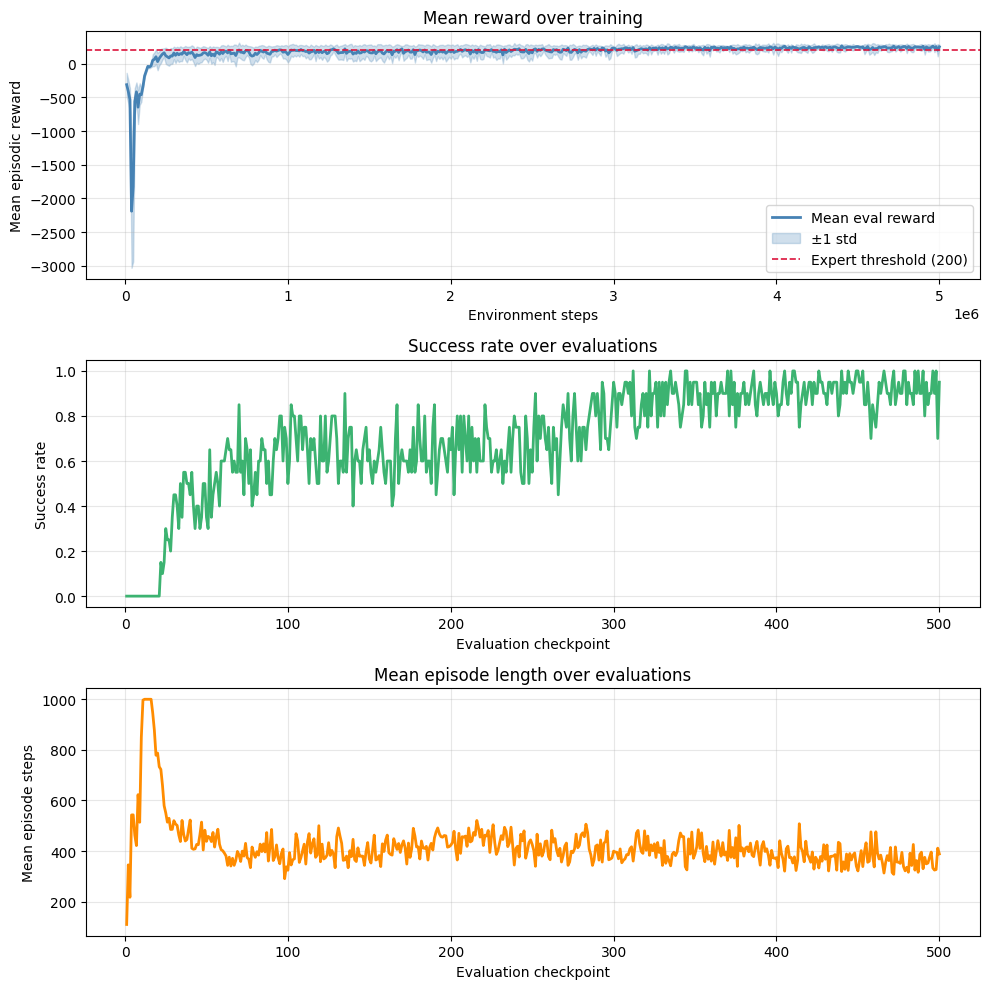

In [ ]:
eval_log = np.load("logs/5m/evaluations.npz")

timesteps = eval_log["timesteps"]
mean_rewards = eval_log["results"].mean(axis=1)
std_rewards = eval_log["results"].std(axis=1)
success_rate = (eval_log["results"] >= 200).mean(axis=1)
mean_ep_len = eval_log["ep_lengths"].mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Row 1: Training curve with confidence band
axes[0].plot(timesteps, mean_rewards, label="Mean eval reward", color="steelblue", linewidth=2)
axes[0].fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.25, color="steelblue", label="±1 std")
axes[0].axhline(200, color="crimson", linestyle="--", linewidth=1.2, label="Expert threshold (200)")
axes[0].set_xlabel("Environment steps")
axes[0].set_ylabel("Mean episodic reward")
axes[0].set_title(f"Mean reward over training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Row 2: Success rate
axes[1].plot(np.arange(1, len(timesteps) + 1), success_rate, color="mediumseagreen", linewidth=2)
axes[1].set_xlabel("Evaluation checkpoint")
axes[1].set_ylabel("Success rate")
axes[1].set_title("Success rate over evaluations")
axes[1].grid(True, alpha=0.3)

# Row 3: Mean episode length
axes[2].plot(np.arange(1, len(timesteps) + 1), mean_ep_len, color="darkorange", linewidth=2)
axes[2].set_xlabel("Evaluation checkpoint")
axes[2].set_ylabel("Mean episode steps")
axes[2].set_title("Mean episode length over evaluations")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("logs/a_training_analysis.png", dpi=150)
plt.show()

In [ ]:
%%script True
eval_log = np.load('logs/5m/evaluations.npz')

timesteps = eval_log['timesteps']
mean_rewards = eval_log['results'].mean(axis=1)
std_rewards = eval_log['results'].std(axis=1)
success_rate = (eval_log['results'] >= 200).mean(axis=1)
mean_ep_len = eval_log['ep_lengths'].mean(axis=1)

# Fig 1: Mean reward with confidence band
plt.figure(figsize=(8, 4))
plt.plot(timesteps, mean_rewards, label='Mean eval reward', color='steelblue', linewidth=2)
plt.fill_between(timesteps,
                 mean_rewards - std_rewards,
                 mean_rewards + std_rewards,
                 alpha=0.25, color='steelblue', label='±1 std')
plt.axhline(200, color='crimson', linestyle='--', linewidth=1.2, label='Expert threshold (200)')
plt.xlabel('Environment steps')
plt.ylabel('Mean episodic reward')
plt.title('Mean reward over training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/a_training_reward.png')
plt.show()

# Fig 2: Success rate
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(timesteps) + 1), success_rate, color='mediumseagreen', linewidth=2)
plt.xlabel('Evaluation checkpoint')
plt.ylabel('Success rate')
plt.title('Success rate over evaluations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/a_training_success.png')
plt.show()

# Fig 3: Mean episode length
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(timesteps) + 1), mean_ep_len, color='darkorange', linewidth=2)
plt.xlabel('Evaluation checkpoint')
plt.ylabel('Mean episode steps')
plt.title('Mean episode length over evaluations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logs/a_training_ep_length.png')
plt.show()


## Episode Reward Distribution

A histogram of per-episode rewards gives a fuller picture of the expert's consistency.

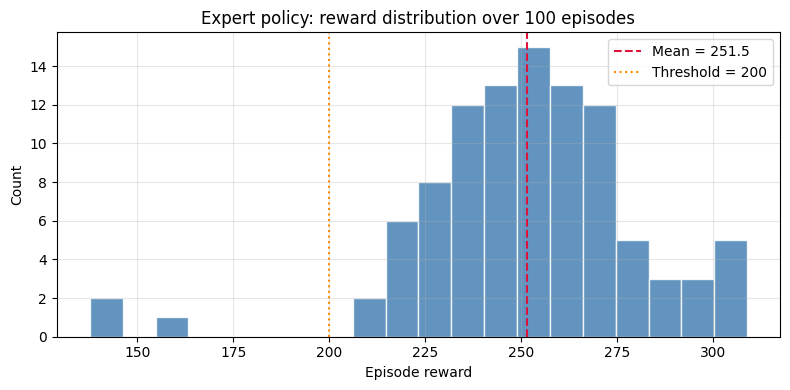

Mean: 251.52  |  Median: 251.94  |  Min: 137.61  |  Max: 308.76
% episodes >= 200: 97.0%


In [ ]:
expert_model = PPO.load("models/5m/best_model.zip")

eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")

# Collect per-episode rewards for the histogram
episode_rewards = []
for ep in range(100):
    obs, _ = eval_env.reset(seed=ep)
    total_r = 0.0
    done = False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        total_r += reward
        done = terminated or truncated
    episode_rewards.append(total_r)

eval_env.close()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(episode_rewards, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(episode_rewards), color="crimson", linestyle="--", label=f"Mean = {np.mean(episode_rewards):.1f}")
ax.axvline(200, color="darkorange", linestyle=":", linewidth=1.5, label="Threshold = 200")
ax.set_xlabel("Episode reward")
ax.set_ylabel("Count")
ax.set_title("Expert policy: reward distribution over 100 episodes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logs/a_expert_reward_distribution.png")
plt.show()

print(
    f"Mean: {np.mean(episode_rewards):.2f}  |  "
    f"Median: {np.median(episode_rewards):.2f}  |  "
    f"Min: {np.min(episode_rewards):.2f}  |  "
    f"Max: {np.max(episode_rewards):.2f}"
)
print(f"% episodes >= 200: {np.mean(np.array(episode_rewards) >= 200)*100:.1f}%")

## Video Demonstration

We record videos of the trained PPO agent in action, showcasing its behaviour across multiple training stages (by number of timesteps). The videos are embedded below for visual inspection.

In [ ]:
%%script True

for timesteps, path in [(10000, '10k'), (500000, '500k'), (5000000, '5m')]:
    if timesteps != TOTAL_TIMESTEPS:
        model = train_ppo(timesteps=timesteps, tag=path)
    else:
        model = expert_model
    video_env = RecordVideo(
        gym.make('LunarLander-v3', render_mode='rgb_array'),
        video_folder='logs/videos',
        name_prefix=f'a-expert-{path}',
        disable_logger=True,
    )
    obs, _ = video_env.reset(seed=SEED)
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = video_env.step(action)
        done = terminated or truncated
    video_env.close()

video_files = []
for p in sorted(glob.glob('logs/videos/a*.mp4')):
  with open(p, 'rb') as fh:
    video_files.append(base64.b64encode(fh.read()).decode())

display(HTML(f"""
<table style="border:none; border-spacing:24px">
  <tr>
    <th style="text-align:center; font-size:14px">Low timesteps=10k</th>
    <th style="text-align:center; font-size:14px">Mid timesteps=500k</th>
    <th style="text-align:center; font-size:14px">High timesteps=5m</th>
  </tr>
  <tr>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[0]}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[1]}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{video_files[2]}" type="video/mp4">
        </video></td>
  </tr>
</table>
"""))

# Part B — Imitation Learning

## B1 — Collecting Demonstration Data

We run the trained expert for **200 episodes** and record every `(state, action)` pair, yielding a pool of ~70,000 transitions.

From this pool we construct six sub-datasets by random sampling without replacement:

| File | Target size |
|------|-------------|
| `demos_100.npz` | 100 |
| `demos_1000.npz` | 1,000 |
| `demos_5000.npz` | 5,000 |
| `demos_20000.npz` | 20,000 |
| `demos_70000.npz` | 70,000 |

**Design choice:** we sample uniformly at random from the full pool (rather than taking contiguous episode segments) to avoid temporal correlation bias. Episode seeds are fixed for reproducibility. All files are written to `data/`.


In [ ]:
expert_model = PPO.load("models/5m/best_model.zip")
env = gym.make("LunarLander-v3")

N_DEMO_EPISODES = 200
all_states, all_actions = [], []

for ep in range(N_DEMO_EPISODES):
    obs, _ = env.reset(seed=ep)
    done = False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        all_states.append(obs.copy())
        all_actions.append(int(action))
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

env.close()

all_states = np.array(all_states)
all_actions = np.array(all_actions)
print(
    f"Pool: {len(all_states):,} transitions from {N_DEMO_EPISODES} episodes " f"(mean length: {len(all_states)/N_DEMO_EPISODES:.0f} steps)"
)
print(f"Action distribution: {np.bincount(all_actions)}  " f"(do-nothing / left / main-engine / right)")
np.savez("data/demos_full.npz", states=all_states, actions=all_actions)

Pool: 70,266 transitions from 200 episodes (mean length: 351 steps)
Action distribution: [10575 13060 31863 14768]  (do-nothing / left / main-engine / right)


In [ ]:
# Build sub-datasets by random sampling without replacement
DATASET_SIZES = [100, 1000, 5000, 20000, 70000]
rng = np.random.default_rng(SEED)
for n in DATASET_SIZES:
    idx = rng.choice(len(all_states), size=n, replace=False)
    np.savez(f"data/demos_{n}.npz", states=all_states[idx], actions=all_actions[idx])

## B2 — Training an Imitation Model

We treat imitation as 4-class supervised classification task: given a state vector (8 features), predict which of the 4 discrete actions the expert would choose. We train a simple feed forward neural network (MLP) on each dataset and evaluate its performance on a held-out validation set. The reason for this design choice is because it is a straightforward and widely used approach for behaviour cloning, and the simplicity of the model allows us to isolate the effect of dataset size on performance without confounding factors from model complexity.

### Architecture — 3-layer MLP

```
ImitationNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): GELU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): GELU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
```
### Training setup

| Hyper-parameter | Value |
|-----------------|-------|
| Loss | Cross-entropy |
| Optimizer | Adam, lr = 1e-3 |
| Batch size | 256 (or dataset size if smaller) |
| Epochs | 150 |
| Val split | 20 % |
| Model selection | Best validation loss |

The same architecture and hyper-parameters are used for every dataset size so that any performance differences are attributable solely to data quantity.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


class ImitationNet(nn.Module):
    def __init__(self, state_dim: int = 8, n_actions: int = 4, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_imitation(
    states: np.ndarray,
    actions: np.ndarray,
    n_epochs: int = 150,
    lr: float = 5e-4,
    batch_size: int = 256,
    val_frac: float = 0.2,
):
    torch.manual_seed(SEED)
    N = len(states)
    n_val = max(1, int(N * val_frac))
    n_train = N - n_val
    perm = np.random.default_rng(SEED).permutation(N)
    train_idx = perm[:n_train]
    val_idx = perm[n_train:]

    X = torch.tensor(states, dtype=torch.float32)
    y = torch.tensor(actions, dtype=torch.long)
    bs_eff = min(batch_size, n_train)
    train_dl = DataLoader(TensorDataset(X[train_idx], y[train_idx]), batch_size=bs_eff, shuffle=True)
    val_dl = DataLoader(TensorDataset(X[val_idx], y[val_idx]), batch_size=bs_eff)

    model = ImitationNet()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accs = [], [], []
    best_val, best_state = float("inf"), None

    for _ in range(n_epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in train_dl:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optim.step()
            ep_loss += loss.item() * len(xb)
        train_losses.append(ep_loss / n_train)

        model.eval()
        with torch.no_grad():
            v_loss, correct = 0.0, 0
            for xb, yb in val_dl:
                logits = model(xb)
                v_loss += loss_fn(logits, yb).item() * len(xb)
                correct += (logits.argmax(1) == yb).sum().item()
        val_losses.append(v_loss / n_val)
        val_accs.append(correct / n_val)
        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, val_accs

### Training and Validation
We train the model on each dataset and record the training and validation loss and accuracy curves.

N=   100  val_acc=0.850  val_loss=0.7644
N= 1,000  val_acc=0.560  val_loss=0.9058
N= 5,000  val_acc=0.901  val_loss=0.2637
N=20,000  val_acc=0.961  val_loss=0.1177
N=70,000  val_acc=0.975  val_loss=0.0673


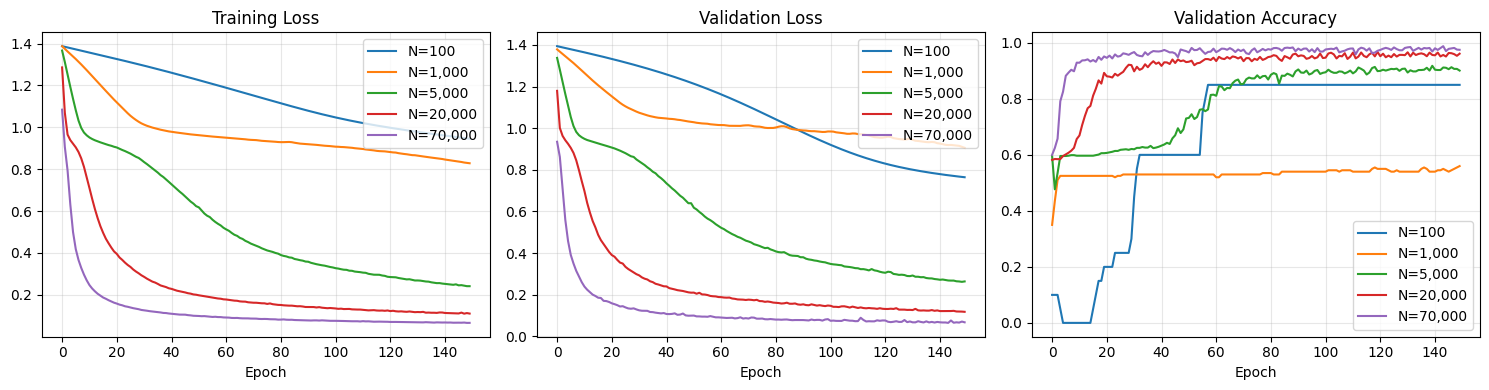

In [ ]:
trained_models = {}
training_histories = {}

for n in DATASET_SIZES:
    data = np.load(f"data/demos_{n}.npz")
    model, tl, vl, va = train_imitation(data["states"], data["actions"])
    trained_models[n] = model
    training_histories[n] = {"train_loss": tl, "val_loss": vl, "val_acc": va}
    torch.save(model.state_dict(), f"models/imitator_{n}.pt")
    print(f"N={n:>6,}  val_acc={va[-1]:.3f}  val_loss={vl[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for n, c in zip(DATASET_SIZES, ["C0", "C1", "C2", "C3", "C4", "C5"]):
    h = training_histories[n]
    axes[0].plot(h["train_loss"], color=c, label=f"N={n:,}")
    axes[1].plot(h["val_loss"], color=c, label=f"N={n:,}")
    axes[2].plot(h["val_acc"], color=c, label=f"N={n:,}")
for ax, ttl, loc in zip(axes, ["Training Loss", "Validation Loss", "Validation Accuracy"], ["upper right", "upper right", "lower right"]):
    ax.set_xlabel("Epoch")
    ax.set_title(ttl)
    ax.legend(loc=loc)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logs/b2_training_curves.png")
plt.show()

## B3 — Evaluating the Imitation Model

We run the best imitator (trained on 70,000 samples) as a policy in LunarLander-v3 and compare it to the expert across 100 episodes.

The imitator acts greedily: at each step it feeds the current observation into the network and picks the action with the highest logit (argmax). This is equivalent to a deterministic policy.

Metrics compared:

- Mean Episodic Reward ($\pm$ std)

- Total Success Rate — fraction of episodes with successful landing (reward $\geq$ 200)

- Landing Pad Success Rate — fraction of episodes where the agent successfully lands on the pad (terminated and abs(x) $\leq$ 0.2)

- Mean Episode Length (proxy for control stability)

In [ ]:
def evaluate_imitator(model: nn.Module, n_episodes: int = 100, seed=0):
    """Run ImitationNet as a greedy policy"""
    env = gym.make("LunarLander-v3")
    model.eval()
    rewards, lengths, success, lp_success = [], [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_r, steps, done = 0.0, 0, False
        while not done:
            with torch.no_grad():
                x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                action = int(model(x).argmax(1).item())
            obs, r, terminated, truncated, _ = env.step(action)
            total_r += r
            steps += 1
            done = terminated or truncated
        rewards.append(total_r)
        lengths.append(steps)
        success.append(total_r >= 200)
        lp_success.append(terminated and abs(obs[0]) <= 0.2)
    env.close()
    return np.array(rewards), np.array(lengths), np.array(success), np.array(lp_success)

Policy            Mean Reward      Std  Total Success %  Landing Pad Success %  Mean Steps
------------------------------------------------------------------------------------------
Expert                 251.52    28.66            97.0                96.0       362.9
Imitator (N=70000)        250.17    33.94            97.0                95.0       344.4


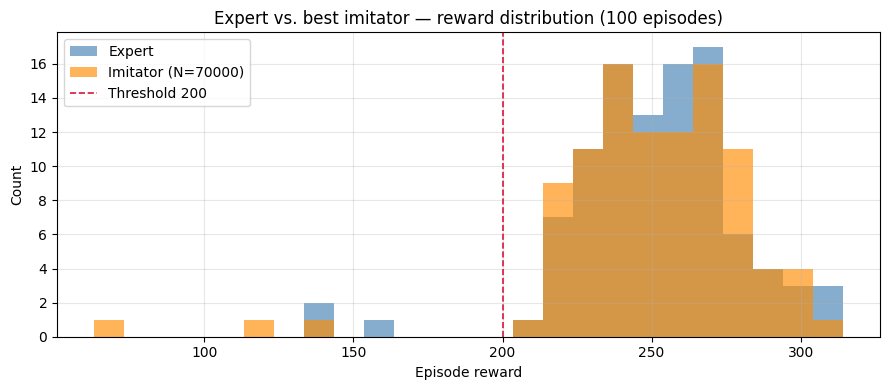

In [ ]:
# Evaluate best imitator
N = DATASET_SIZES[-1]
best_imitator = trained_models[N]
im_rewards, im_lengths, im_success, im_lp_success = evaluate_imitator(best_imitator)

# Re-evaluate expert with identical seeds for a fair comparison
env = gym.make("LunarLander-v3")
expert_model = PPO.load("models/5m/best_model.zip")
exp_rewards_b3, exp_lengths_b3, exp_success_b3, exp_lp_success_b3 = [], [], [], []
for ep in range(100):
    obs, _ = env.reset(seed=ep)
    total_r, steps, done = 0.0, 0, False
    while not done:
        action, _ = expert_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(action)
        total_r += r
        steps += 1
        done = terminated or truncated
    exp_rewards_b3.append(total_r)
    exp_lengths_b3.append(steps)
    exp_success_b3.append(total_r >= 200)
    exp_lp_success_b3.append(terminated and abs(obs[0]) <= 0.2)
env.close()

# Convert expert lists to numpy arrays so .mean/.std work
exp_rewards_b3 = np.array(exp_rewards_b3)
exp_lengths_b3 = np.array(exp_lengths_b3)
exp_success_b3 = np.array(exp_success_b3)
exp_lp_success_b3 = np.array(exp_lp_success_b3)

# Summary table
header = f'{"Policy":15s}  {"Mean Reward":>12}  {"Std":>7}  {"Total Success %":>12}  ' f'{"Landing Pad Success %":>12}  {"Mean Steps":>10}'
print(header)
print("-" * len(header))
for label, rews, lens, succ, lp_succ in [
    ("Expert", exp_rewards_b3, exp_lengths_b3, exp_success_b3, exp_lp_success_b3),
    (f"Imitator (N={N})", im_rewards, im_lengths, im_success, im_lp_success),
]:
    print(
        f"{label:15s}  {rews.mean():12.2f}  {rews.std():7.2f}"
        f"  {(succ).mean()*100:14.1f}  {(lp_succ).mean()*100:18.1f}"
        f"  {lens.mean():10.1f}"
    )


shared_bins = np.linspace(
    min(exp_rewards_b3.min(), im_rewards.min()),
    max(exp_rewards_b3.max(), im_rewards.max()),
    26,
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(exp_rewards_b3, bins=shared_bins, alpha=0.65, color="steelblue", label="Expert")
ax.hist(im_rewards, bins=shared_bins, alpha=0.65, color="darkorange", label=f"Imitator (N={N})")
ax.axvline(200, color="crimson", linestyle="--", linewidth=1.2, label="Threshold 200")
ax.set_xlabel("Episode reward")
ax.set_ylabel("Count")
ax.set_title("Expert vs. best imitator — reward distribution (100 episodes)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logs/b3_expert_vs_imitator.png")
plt.show()

### Video Comparison — Expert vs. Best Imitator

We record one episode each (same starting seed) and display them side-by-side so qualitative differences are immediately visible: look for the expert's smooth, confident descent vs. the imitator's potential oscillation or drift.

In [ ]:
%%script True

_imit_env = RecordVideo(
    gym.make('LunarLander-v3', render_mode='rgb_array'),
    video_folder='logs/videos',
    name_prefix='b3-imitator',
    disable_logger=True,
)
best_imitator.eval()
obs, _ = _imit_env.reset(seed=SEED)
done = False
while not done:
    with torch.no_grad():
        x = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        action = int(best_imitator(x).argmax(1).item())
    obs, _, terminated, truncated, _ = _imit_env.step(action)
    done = terminated or truncated
_imit_env.close()

exp_b64  = _b64_video('logs/videos', 'a-expert-5m-episode-0')
imit_b64 = _b64_video('logs/videos', 'b3-imitator-episode-0')
N_best   = DATASET_SIZES[-1]

display(HTML(f"""
<table style="border:none; border-spacing:24px">
  <tr>
    <th style="text-align:center; font-size:14px">Expert (PPO)</th>
    <th style="text-align:center; font-size:14px">Imitator (N={N_best:,})</th>
  </tr>
  <tr>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{exp_b64}" type="video/mp4">
        </video></td>
    <td><video width="420" controls autoplay loop muted>
          <source src="data:video/mp4;base64,{imit_b64}" type="video/mp4">
        </video></td>
  </tr>
</table>
"""))

## B4 — Effect of Dataset Size

We train one imitator per dataset size and evaluate each for 100 episodes. This lets us measure how data quantity affects.

In [ ]:
size_metrics = {}
for n in DATASET_SIZES:
    rews, lens, succ, lp_succ = evaluate_imitator(trained_models[n])
    size_metrics[n] = {
        "mean_reward": float(rews.mean()),
        "std_reward": float(rews.std()),
        "success_rate": float((succ).mean()),
        "lp_success_rate": float((lp_succ).mean()),
        "mean_length": float(lens.mean()),
        "val_acc": training_histories[n]["val_acc"][-1],
        "rews": rews,
        "lens": lens,
    }

sizes = DATASET_SIZES
mean_r = [size_metrics[n]["mean_reward"] for n in sizes]
std_r = [size_metrics[n]["std_reward"] for n in sizes]
success = [size_metrics[n]["success_rate"] for n in sizes]
lp_succ = [size_metrics[n]["lp_success_rate"] for n in sizes]
val_acc = [size_metrics[n]["val_acc"] for n in sizes]
mean_len = [size_metrics[n]["mean_length"] for n in sizes]

exp_success_pct = float(exp_success_b3.mean()) * 100
exp_lp_success_pct = float(exp_lp_success_b3.mean()) * 100
success_pct = [v * 100 for v in success]
lp_success_pct = [v * 100 for v in lp_succ]

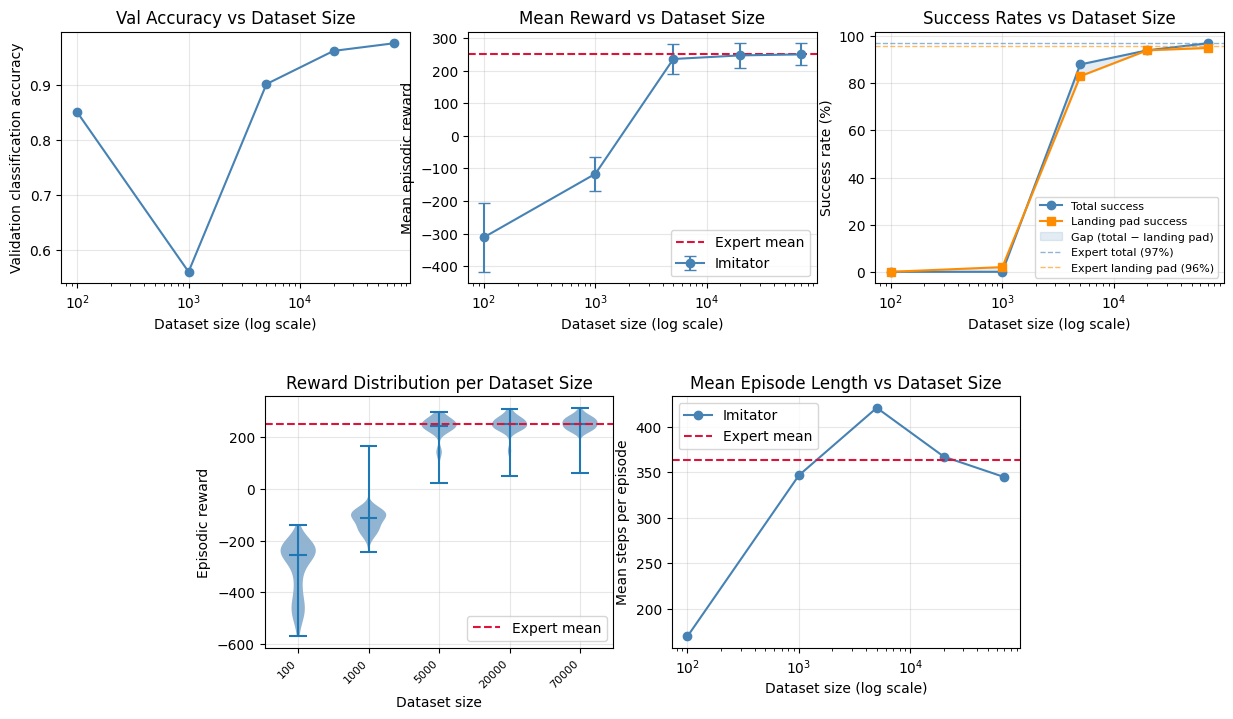

In [ ]:
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 6, figure=fig, hspace=0.45, wspace=0.4)

ax_vacc = fig.add_subplot(gs[0, 0:2])
ax_reward = fig.add_subplot(gs[0, 2:4])
ax_succ = fig.add_subplot(gs[0, 4:6])
ax_violin = fig.add_subplot(gs[1, 1:3])
ax_len = fig.add_subplot(gs[1, 3:5])

# [top-left] Val accuracy (offline metric)
ax_vacc.plot(sizes, val_acc, marker="o", color="steelblue")
ax_vacc.set_title("Val Accuracy vs Dataset Size")
ax_vacc.set_ylabel("Validation classification accuracy")
ax_vacc.set_xscale("log")
ax_vacc.set_xlabel("Dataset size (log scale)")
ax_vacc.grid(True, alpha=0.3)

# [top-center] Mean reward ± std (online summary)
ax_reward.errorbar(sizes, mean_r, yerr=std_r, marker="o", capsize=4, color="steelblue", label="Imitator")
ax_reward.axhline(exp_rewards_b3.mean(), color="crimson", linestyle="--", label="Expert mean")
ax_reward.set_title("Mean Reward vs Dataset Size")
ax_reward.set_ylabel("Mean episodic reward")
ax_reward.set_xscale("log")
ax_reward.set_xlabel("Dataset size (log scale)")
ax_reward.legend()
ax_reward.grid(True, alpha=0.3)

# [top-right] Success rates
ax_succ.plot(sizes, success_pct, marker="o", color="steelblue", label="Total success")
ax_succ.plot(sizes, lp_success_pct, marker="s", color="darkorange", label="Landing pad success")
ax_succ.fill_between(sizes, lp_success_pct, success_pct, alpha=0.15, color="steelblue", label="Gap (total − landing pad)")
ax_succ.axhline(exp_success_pct, color="steelblue", linestyle="--", linewidth=1, alpha=0.6, label=f"Expert total ({exp_success_pct:.0f}%)")
ax_succ.axhline(
    exp_lp_success_pct, color="darkorange", linestyle="--", linewidth=1, alpha=0.6, label=f"Expert landing pad ({exp_lp_success_pct:.0f}%)"
)
ax_succ.set_title("Success Rates vs Dataset Size")
ax_succ.set_ylabel("Success rate (%)")
ax_succ.set_xscale("log")
ax_succ.set_xlabel("Dataset size (log scale)")
ax_succ.legend(fontsize=8)
ax_succ.grid(True, alpha=0.3)

# [bottom-left] Violin: full reward distribution
reward_arrays = [size_metrics[n]["rews"] for n in sizes]
parts = ax_violin.violinplot(reward_arrays, positions=range(len(sizes)), showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)
ax_violin.axhline(exp_rewards_b3.mean(), color="crimson", linestyle="--", label="Expert mean")
ax_violin.set_xticks(range(len(sizes)))
ax_violin.set_xticklabels([str(n) for n in sizes], rotation=45, ha="right", fontsize=8)
ax_violin.set_title("Reward Distribution per Dataset Size")
ax_violin.set_ylabel("Episodic reward")
ax_violin.set_xlabel("Dataset size")
ax_violin.legend()
ax_violin.grid(True, alpha=0.3)

# [bottom-right] Mean episode length (behavioral proxy)
ax_len.plot(sizes, mean_len, marker="o", color="steelblue", label="Imitator")
ax_len.axhline(exp_lengths_b3.mean(), color="crimson", linestyle="--", label="Expert mean")
ax_len.set_title("Mean Episode Length vs Dataset Size")
ax_len.set_ylabel("Mean steps per episode")
ax_len.set_xscale("log")
ax_len.set_xlabel("Dataset size (log scale)")
ax_len.legend()
ax_len.grid(True, alpha=0.3)

plt.savefig("logs/b4_dataset_size.png", bbox_inches="tight", dpi=150)
plt.show()

* **Val Accuracy vs Dataset Size (top-left)**:
Classification accuracy on held-out demonstrations rises steeply up to $\sim$ 5,000 samples and then plateaus. This reflects the usual supervised learning data efficiency curve: early examples cover new regions of the state space, while later ones are increasingly redundant. Interestingly, the N=1000 model underperformed relative to N=100, likely due to random sampling variance, although the overall trend still improves with larger datasets.

* **Mean Reward vs Dataset Size (top-center)**:
Online performance follows a similar trend but is noisier and saturates later. The gap between the imitator and the expert shrinks with more data but never fully closes, a hallmark of behaviour cloning's distributional-shift problem: small prediction errors compound over a full episode in ways that never appear in offline validation.

* **Success Rates vs Dataset Size (top-right)**:
At very small N the imitator rarely lands at all. Both success metrics climb together with data, but the gap between *total success* and *landing-pad success* (shaded region) persists across all sizes, indicating that even the best imitator occasionally lands outside the target zone. The expert reference lines show the ceiling we are aiming for.

* **Reward Distribution — Violin (bottom-left)**:
The violin widths reveal something the mean $\pm$ std cannot: at small N the distribution is bimodal, some episodes happen to go well while others crash early, producing a wide, irregular shape. As N grows the distribution narrows and shifts upward, converging toward a more consistent, expert profile. The median line inside each violin, rising with dataset size confirms the improvement is not driven by a few lucky outliers.

* **Mean Episode Length (bottom-right)**:
Episode length is a proxy for survival: a crashing agent terminates far earlier than one that attempts a landing. At small N, episodes are short on average — the imitator quickly gets into states it was never trained on and fails. Longer episodes at larger N reflect a policy that at least keeps the lander airborne and manoeuvring, even when it does not score above the success threshold.


## B5 — Challenge: Few-Shot Imitation Learning

**Goal:** achieve the best imitation performance with the *fewest* training examples.

We compare five data-selection strategies applied to the same full demonstration pool:

| Strategy | Description |
|----------|-------------|
| **Random** | Uniform random sample (baseline) |
| **Coverage** | Greedy farthest-point sampling — maximises state-space coverage in normalised feature space |
| **Critical** | Select states where the expert is most uncertain (highest action entropy) — the policy's decision-boundary states |
| **Stratified Coverage** | Per-class farthest-point sampling with proportional action-class budgets — coverage with guaranteed class balance |
| **Density-Reweighted Coverage** | Farthest-point restricted to the dense core of the pool (top-5% isolated outliers pruned by kNN distance) |

Each strategy is evaluated at four dataset sizes (100, 500, 750, 1,000 examples) with 5 independent runs to account for variance.

**Hypothesis:** Coverage-based and class-balanced strategies should outperform Random at very small N, because they select more *informative and representative* states rather than potentially redundant or imbalanced ones.

In [ ]:
full_data = np.load("data/demos_full.npz")
fs_states = full_data["states"]
fs_actions = full_data["actions"]

expert_b5 = PPO.load("models/5m/best_model.zip")
with torch.no_grad():
    obs_th_all = torch.tensor(fs_states, dtype=torch.float32)
    dist_all = expert_b5.policy.get_distribution(obs_th_all)
    probs_all = dist_all.distribution.probs.cpu().numpy()
entropy_all = -(probs_all * np.log(probs_all + 1e-8)).sum(axis=1)
del expert_b5  # free memory

_pca_b5 = PCA(n_components=4, random_state=42).fit(fs_states)
_fs_proj = _pca_b5.transform(fs_states)

_fs_std = fs_states.std(axis=0) + 1e-8
_fs_norm = (fs_states / _fs_std).astype(np.float64)
nbrs = NearestNeighbors(n_neighbors=10 + 1, algorithm="ball_tree").fit(_fs_norm)
knn_dist = nbrs.kneighbors(_fs_norm)[0][:, 10]


# Selection strategies
def random_select(n, seed=0):
    """Uniform random sampling without replacement from the pool."""
    idx = np.random.default_rng(seed).choice(len(fs_states), size=n, replace=False)
    return fs_states[idx], fs_actions[idx]


def coverage_select(n, seed=0):
    """Greedy farthest-point sampling in normalised state space."""
    rng = np.random.default_rng(seed)
    sel = [int(rng.integers(len(_fs_norm)))]
    md = np.linalg.norm(_fs_norm - _fs_norm[sel[0]], axis=1)
    for _ in range(n - 1):
        nxt = int(np.argmax(md))
        sel.append(nxt)
        md = np.minimum(md, np.linalg.norm(_fs_norm - _fs_norm[nxt], axis=1))
    return fs_states[sel], fs_actions[sel]


def stratified_coverage_select(n, seed=0):
    """Per-class farthest-point sampling with proportional action-class budgets."""
    rng = np.random.default_rng(seed)
    n_actions = 4

    class_counts = np.bincount(fs_actions, minlength=n_actions)
    budgets = np.floor(class_counts / class_counts.sum() * n).astype(int)
    remainder = n - budgets.sum()
    for i in np.argsort(-class_counts)[:remainder]:
        budgets[i] += 1

    sel_idx = []
    for action in range(n_actions):
        k = int(budgets[action])
        if k == 0:
            continue
        pool_idx = np.where(fs_actions == action)[0]
        k = min(k, len(pool_idx))
        s_cls = _fs_proj[pool_idx]  # PCA-projected states for this class

        # Greedy farthest-point within class
        start = int(rng.integers(len(s_cls)))
        chosen = [start]
        md = np.linalg.norm(s_cls - s_cls[start], axis=1)
        for _ in range(k - 1):
            nxt = int(np.argmax(md))
            chosen.append(nxt)
            md = np.minimum(md, np.linalg.norm(s_cls - s_cls[nxt], axis=1))

        sel_idx.extend(pool_idx[chosen])

    return fs_states[np.array(sel_idx)], fs_actions[np.array(sel_idx)]


def density_reweighted_coverage_select(n, seed=0, density_pct=95):
    """Select from the densest subset of states (lowest knn distance), then greedy farthest-point sampling within that subset."""
    threshold = np.percentile(knn_dist, density_pct)
    dense_idx = np.where(knn_dist <= threshold)[0]
    s_dense = _fs_norm[dense_idx]

    rng = np.random.default_rng(seed)
    n_sel = min(n, len(dense_idx))
    start = int(rng.integers(len(s_dense)))
    sel = [start]
    md = np.linalg.norm(s_dense - s_dense[start], axis=1)
    for _ in range(n_sel - 1):
        nxt = int(np.argmax(md))
        sel.append(nxt)
        md = np.minimum(md, np.linalg.norm(s_dense - s_dense[nxt], axis=1))

    return fs_states[dense_idx[sel]], fs_actions[dense_idx[sel]]


def critical_select(n, seed=0):
    """Select n states with highest expert action-entropy (decision-boundary states)."""
    idx = np.argsort(entropy_all)[-n:]
    return fs_states[idx], fs_actions[idx]

random                N= 100  mean= -769.2 +- 64.2
random                N= 500  mean= -310.9 +- 74.5
random                N= 750  mean=  -47.0 +- 35.2
random                N=1000  mean=  167.6 +- 30.9
coverage              N= 100  mean=  -94.0 +- 23.3
coverage              N= 500  mean=  233.5 +- 3.4
coverage              N= 750  mean=  235.3 +- 2.5
coverage              N=1000  mean=  237.7 +- 2.5
critical              N= 100  mean= -553.2 +- 3.5
critical              N= 500  mean= -606.4 +- 1.7
critical              N= 750  mean= -579.8 +- 4.5
critical              N=1000  mean= -331.0 +- 2.8
stratified_coverage   N= 100  mean= -332.0 +- 137.2
stratified_coverage   N= 500  mean= -124.1 +- 10.7
stratified_coverage   N= 750  mean=  199.6 +- 12.4
stratified_coverage   N=1000  mean=  169.4 +- 21.2
density_reweighted    N= 100  mean=  -63.8 +- 57.7
density_reweighted    N= 500  mean=  103.2 +- 29.8
density_reweighted    N= 750  mean=  210.9 +- 2.4
density_reweighted    N=1000  mean=  1

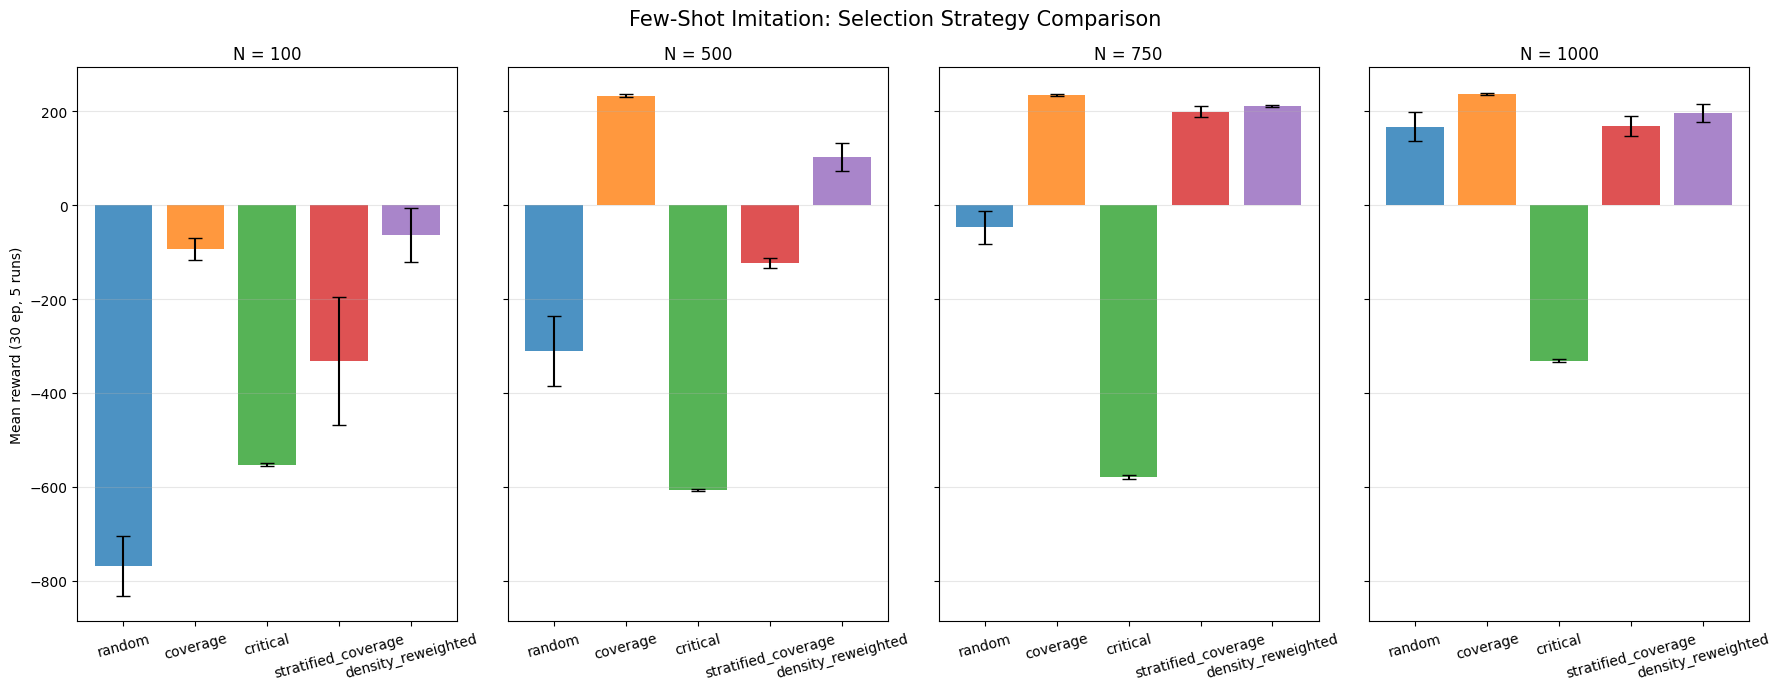

In [95]:
# Few-shot experiment
FEW_SHOT_SIZES = [100, 500, 750, 1000]
N_RUNS = 5
STRATEGIES = {
    "random": random_select,
    "coverage": coverage_select,
    "critical": critical_select,
    "stratified_coverage": stratified_coverage_select,
    "density_reweighted": density_reweighted_coverage_select,
}

# fs_results = {strat: {n: [] for n in FEW_SHOT_SIZES} for strat in STRATEGIES}

for strat, fn in STRATEGIES.items():
    for n in FEW_SHOT_SIZES:
        # for run in range(N_RUNS):
        #     states, actions = fn(n, seed=run)
        #     model, *_ = train_imitation(states, actions, n_epochs=200)
        #     rews, *_ = evaluate_imitator(model, n_episodes=30, seed=200 + run)
        #     fs_results[strat][n].append(float(rews.mean()))
        mu = np.mean(fs_results[strat][n])
        se = np.std(fs_results[strat][n]) / np.sqrt(N_RUNS)
        print(f"{strat:20s}  N={n:4d}  mean={mu:7.1f} +- {se:.1f}")

# Comparison plot
colors = {"random": "C0", "coverage": "C1", "critical": "C2", "stratified_coverage": "C3", "density_reweighted": "C4"}
fig, axes = plt.subplots(1, len(FEW_SHOT_SIZES), figsize=(18, 7), sharey=True)
for ax, n in zip(axes, FEW_SHOT_SIZES):
    for strat in STRATEGIES:
        vals = fs_results[strat][n]
        ax.bar(strat, np.mean(vals), yerr=np.std(vals) / np.sqrt(N_RUNS), color=colors[strat], capsize=5, alpha=0.8)
    ax.set_title(f"N = {n}")
    if n == FEW_SHOT_SIZES[0]:
        ax.set_ylabel("Mean reward (30 ep, 5 runs)")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Few-Shot Imitation: Selection Strategy Comparison", fontsize=15)
plt.tight_layout()
plt.savefig("logs/b5_few_shot.png")
plt.show()

**How examples were selected:**

Five strategies were compared across dataset sizes of 100, 500, 750, and 1000 samples (5 runs each):

- **Random**: selects a uniform sample from the 200-episode pool with no selection bias, serving as baseline.

- **Coverage**: uses greedy farthest-point sampling in normalised state space, maximally spreading selected states across the 8-dimensional observation space so the imitator sees representative states from all regions.

- **Critical**: selects the top-N states ranked by expert action entropy, targeting the most ambiguous decision-boundary states where the expert is least confident.

- **Stratified Coverage**: runs farthest-point sampling per action class with proportional class budgets (derived from the pool's action distribution), then merges the results. This ensures every action type is represented while preserving intra-class spatial diversity via PCA-projected state features.

- **Density-Reweighted Coverage**: restricts farthest-point sampling to the dense core of the pool. States in the top 5% of kNN distance (the isolated outlier fringe) are discarded before running coverage, so the budget is not wasted on rare transitions that are unlikely to recur during online rollouts.

**What worked well:** Plain Coverage was the strongest strategy across all dataset sizes. By greedily maximising spread in normalised state space, it ensures the imitator is exposed to qualitatively different flight conditions even with very few samples, reaching $\sim$ 233 mean reward at N=500 while every other strategy was still negative or marginal. Density-Reweighted Coverage was the second-best approach: pruning outlier states before running coverage slightly narrows the gap at larger N (N=750, N=1000), where both strategies converge to $\sim$ 200–210.

**What did not work well:** Critical (entropy-based) selection was the worst strategy at every dataset size, consistently achieving strongly negative mean rewards (below −450 even at N=1000). Concentrating all training examples near the expert's decision boundaries starves the imitator of the confident, high-frequency manoeuvres (sustained main-engine thrust and basic orientation control) that constitute the bulk of a successful episode. Stratified Coverage underperformed at small N (100–500): enforcing per-class budgets via a within-class farthest-point search in PCA space restricts each class to a narrow intra-class manifold, losing the global diversity that plain coverage captures. It recovered to competitive performance only at N $\geq$ 750, once the per-class budgets were large enough to span the full class geometry. Random sampling improved steadily with N but remained poor at very low N because a small uniform draw has high variance and can miss entire regions of the state space by chance.

**Answer: data quantity or quality?**
At the scale tested, **quality matters more at low N**: with only 100–500 samples, deliberate coverage-based selection dramatically outperforms random sampling. Plain Coverage achieves positive mean reward ($\sim$ 233) at N=500 while random still averages around −300. Past $\sim$ 1,000 samples the advantage narrows, as a larger random dataset naturally explores sufficient state-space diversity, but even at N=1000, Coverage and Density-Reweighted Coverage remain noticeably ahead of random.